#Importing the Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

The Dataset can be downloaded form here. https://www.kaggle.com/datasets/adityakadiwal/water-potability

In [2]:
main_df = pd.read_csv("water_potability.csv")
df = main_df.copy() #Making a acopy of the dataset to work on

# Understanding The Data

1. **ph**: pH of 1. water (0 to 14).
2. **Hardness**: Capacity of water to precipitate soap in mg/L.
3. **Solids**: Total dissolved solids in ppm.
4. **Chloramines**: Amount of Chloramines in ppm.
5. **Sulfate**: Amount of Sulfates dissolved in mg/L.
6. **Conductivity**: Electrical conductivity of water in μS/cm.
7. **Organic_carbon**: Amount of organic carbon in ppm.
8. **Trihalomethanes**: Amount of Trihalomethanes in μg/L.
9. **Turbidity**: Measure of light emiting property of water in NTU.
10. **Potability**: Indicates if water is safe for human consumption. Potable -1 and Not potable -0

In [3]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [4]:
df.shape

(3276, 10)

In [5]:
df.columns

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='object')

In [6]:
df.dtypes

ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object

***Observation:*** our dataset has 3276 rows and 10 columns and we have 9 features having numerical values and 1 feature(potability) having categorical values.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [8]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


From the above table, we can see that the count of each feature are not same. so there must me some null values.
Feature Solids has the high mean and standard deviation compared to other features.

In [9]:
#Distribution of Potability Values
df['Potability'].value_counts(normalize=True)

Potability
0    0.60989
1    0.39011
Name: proportion, dtype: float64

# Exploratory Data Analysis


In [10]:
print(df.nunique())

ph                 2785
Hardness           3276
Solids             3276
Chloramines        3276
Sulfate            2495
Conductivity       3276
Organic_carbon     3276
Trihalomethanes    3114
Turbidity          3276
Potability            2
dtype: int64


In [11]:
#Finding the missing value on different columns
print(df.isnull().sum())

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


In the dataset we have 491 null values of ph , 781 null values for sulfate and 162 null values for Trihalomethanes. which is quite large for data handling we can remove nulls but our dataset is already small, if we remove null value column then in worst case approx 20% of our data will get deleted , so we have to do some more analysis to find the alternative way

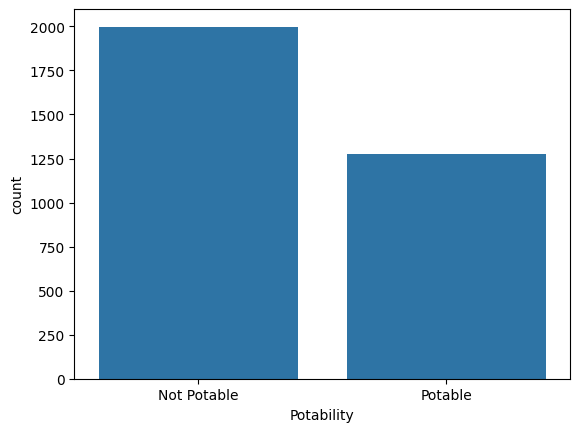

In [12]:
ax = sns.countplot(x = "Potability",data= df, saturation=0.8)
plt.xticks(ticks=[0, 1], labels = ["Not Potable", "Potable"])
plt.show()

Potability
0    1998
1    1278
Name: count, dtype: int64


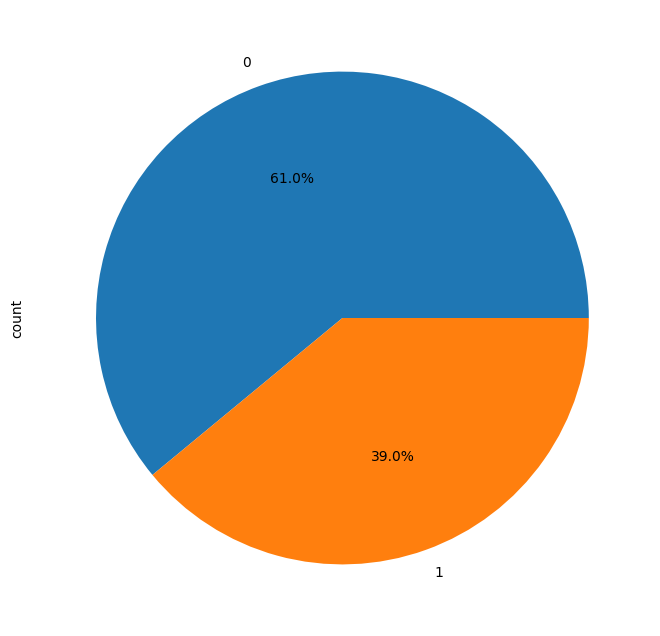

In [13]:
print(df["Potability"].value_counts())
df["Potability"].value_counts().plot(kind="pie", autopct='%1.1f%%',figsize=(8,8));

The above graph shows that in our dataset there's 39% data is potable and  61% data is not potable. So, there is imbalance in the data which can make model biased.




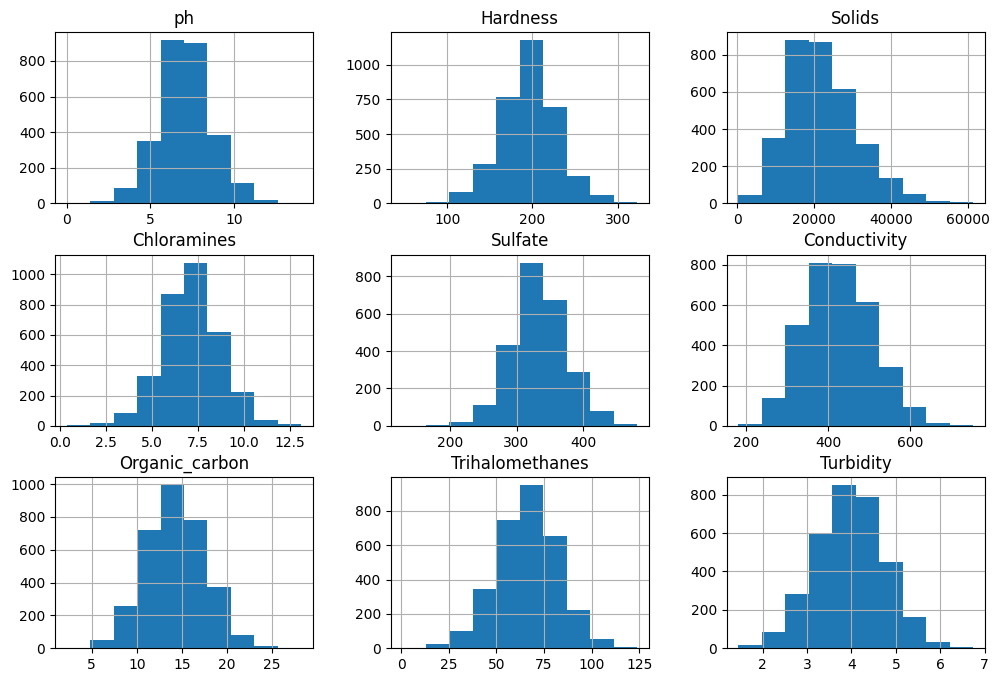

In [14]:
#Distribution of Different Parameters
df.drop('Potability', axis=1).hist(figsize=(12,8));

above histogram shows, that all the features of the dataset are distributed normally with the small amount of skewness . as we know that our dataset is imbalance but it is normally distributed , so we can work upon this dataset.

In [15]:
df.corr()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
ph,1.000000,0.082096,-0.089288,-0.034350,0.018203,0.018614,0.043503,0.003354,-0.039057,-0.003556
Hardness,0.082096,1.000000,-0.046899,-0.030054,-0.106923,-0.023915,0.003610,-0.013013,-0.014449,-0.013837
Solids,-0.089288,-0.046899,1.000000,-0.070148,-0.171804,0.013831,0.010242,-0.009143,0.019546,0.033743
Chloramines,-0.034350,-0.030054,-0.070148,1.000000,0.027244,-0.020486,-0.012653,0.017084,0.002363,0.023779
Sulfate,0.018203,-0.106923,-0.171804,0.027244,1.000000,-0.016121,0.030831,-0.030274,-0.011187,-0.023577
Conductivity,0.018614,-0.023915,0.013831,-0.020486,-0.016121,1.000000,0.020966,0.001285,0.005798,-0.008128
Organic_carbon,0.043503,0.003610,0.010242,-0.012653,0.030831,0.020966,1.000000,-0.013274,-0.027308,-0.030001
Trihalomethanes,0.003354,-0.013013,-0.009143,0.017084,-0.030274,0.001285,-0.013274,1.000000,-0.022145,0.007130
Turbidity,-0.039057,-0.014449,0.019546,0.002363,-0.011187,0.005798,-0.027308,-0.022145,1.000000,0.001581
Potability,-0.003556,-0.013837,0.033743,0.023779,-0.023577,-0.008128,-0.030001,0.007130,0.001581,1.000000


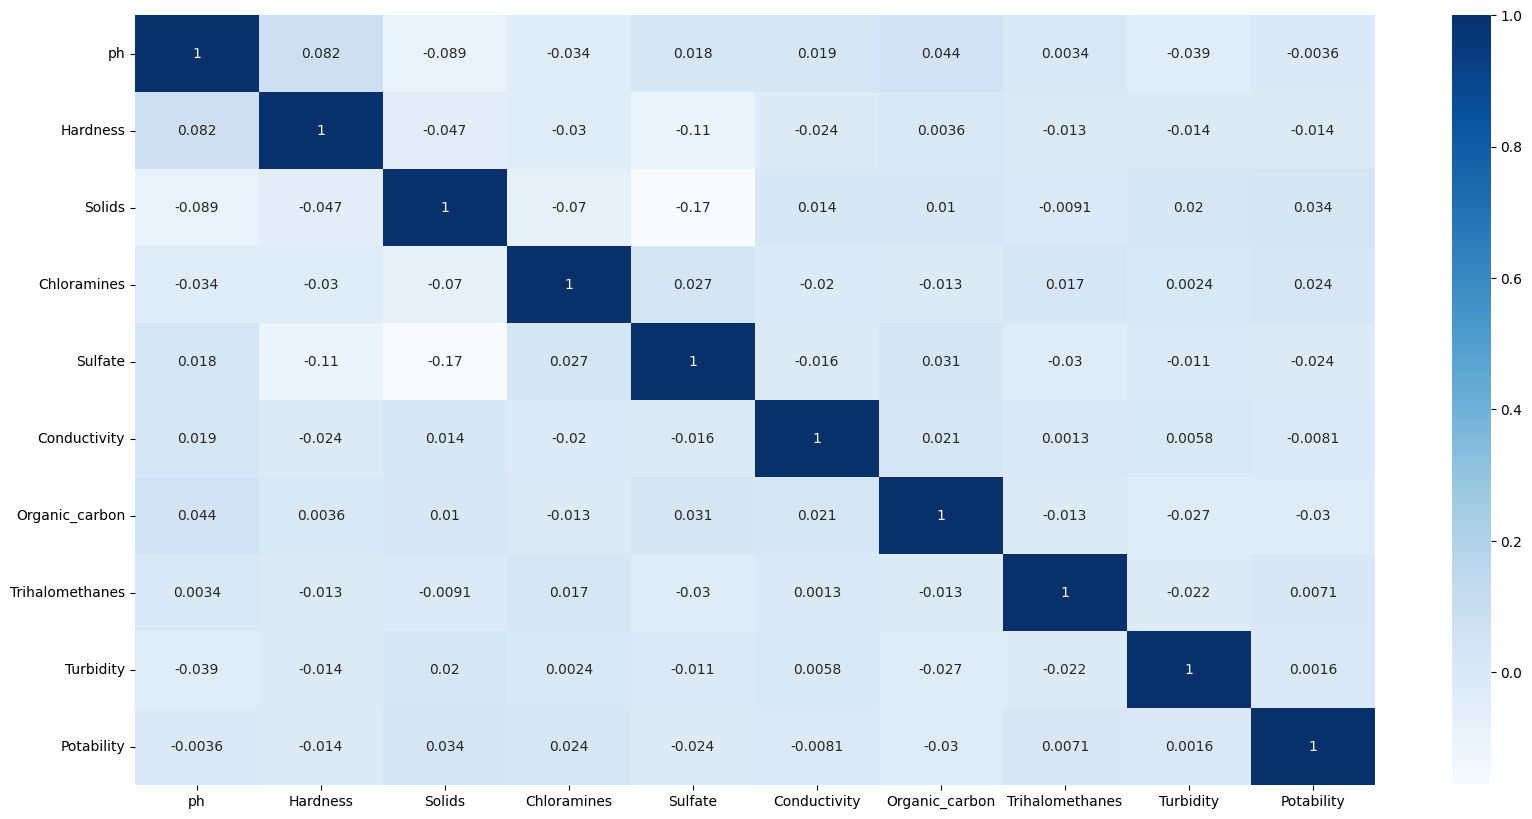

In [16]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(), cmap='Blues', annot=True)
plt.show()

Heatmap describes the correlation between the features, and  the correlation values between most of these features are close to zero or very low,This indicates that the features are not strongly correlated with each other.it implies that the features are likely to have high dimensionality which can increase the computational complexity.

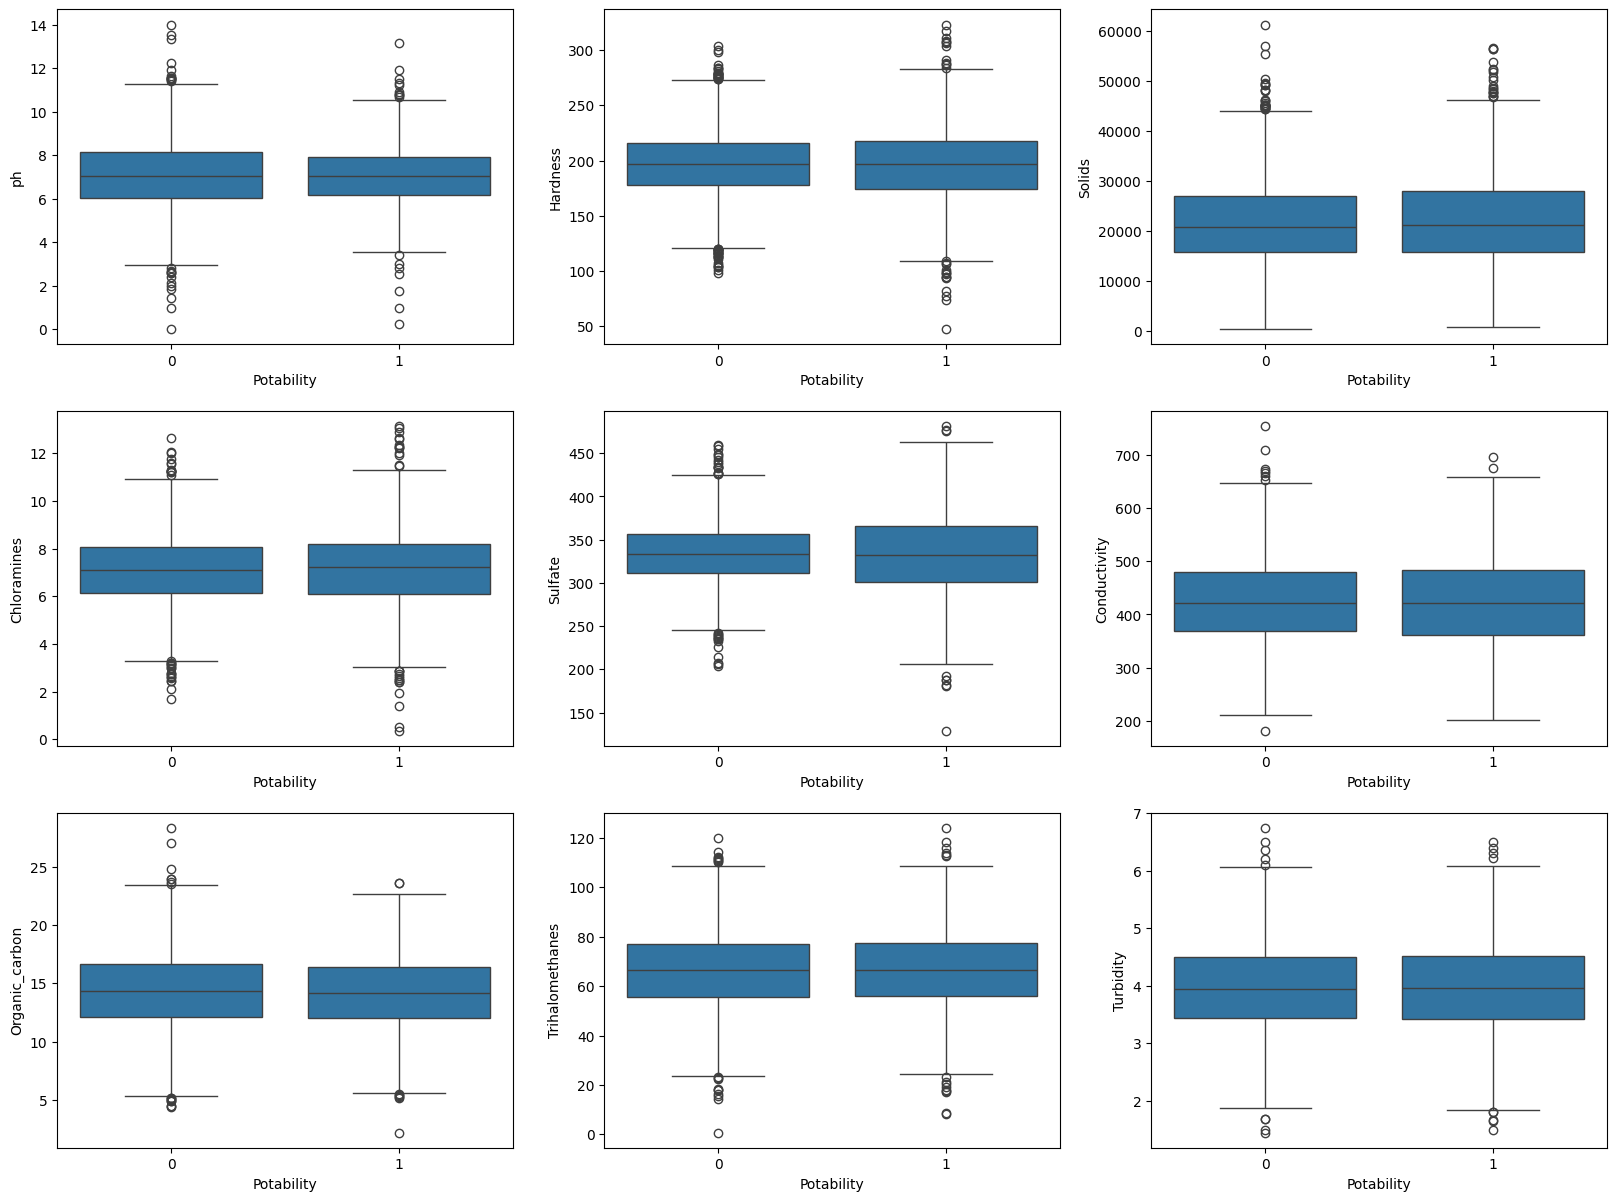

In [17]:
index = 0
plt.figure(figsize=(20, 20))
for feature in df.columns:
    if feature != "Potability":
        index += 1
        plt.subplot(4, 3, index)
        sns.boxplot(x='Potability', y=feature, data=df)

here we can see that we have significant amount of outliers , but we choose to not to remove them as they are extreme values for which water can be not potable / potable , these type of values will help our model to train.

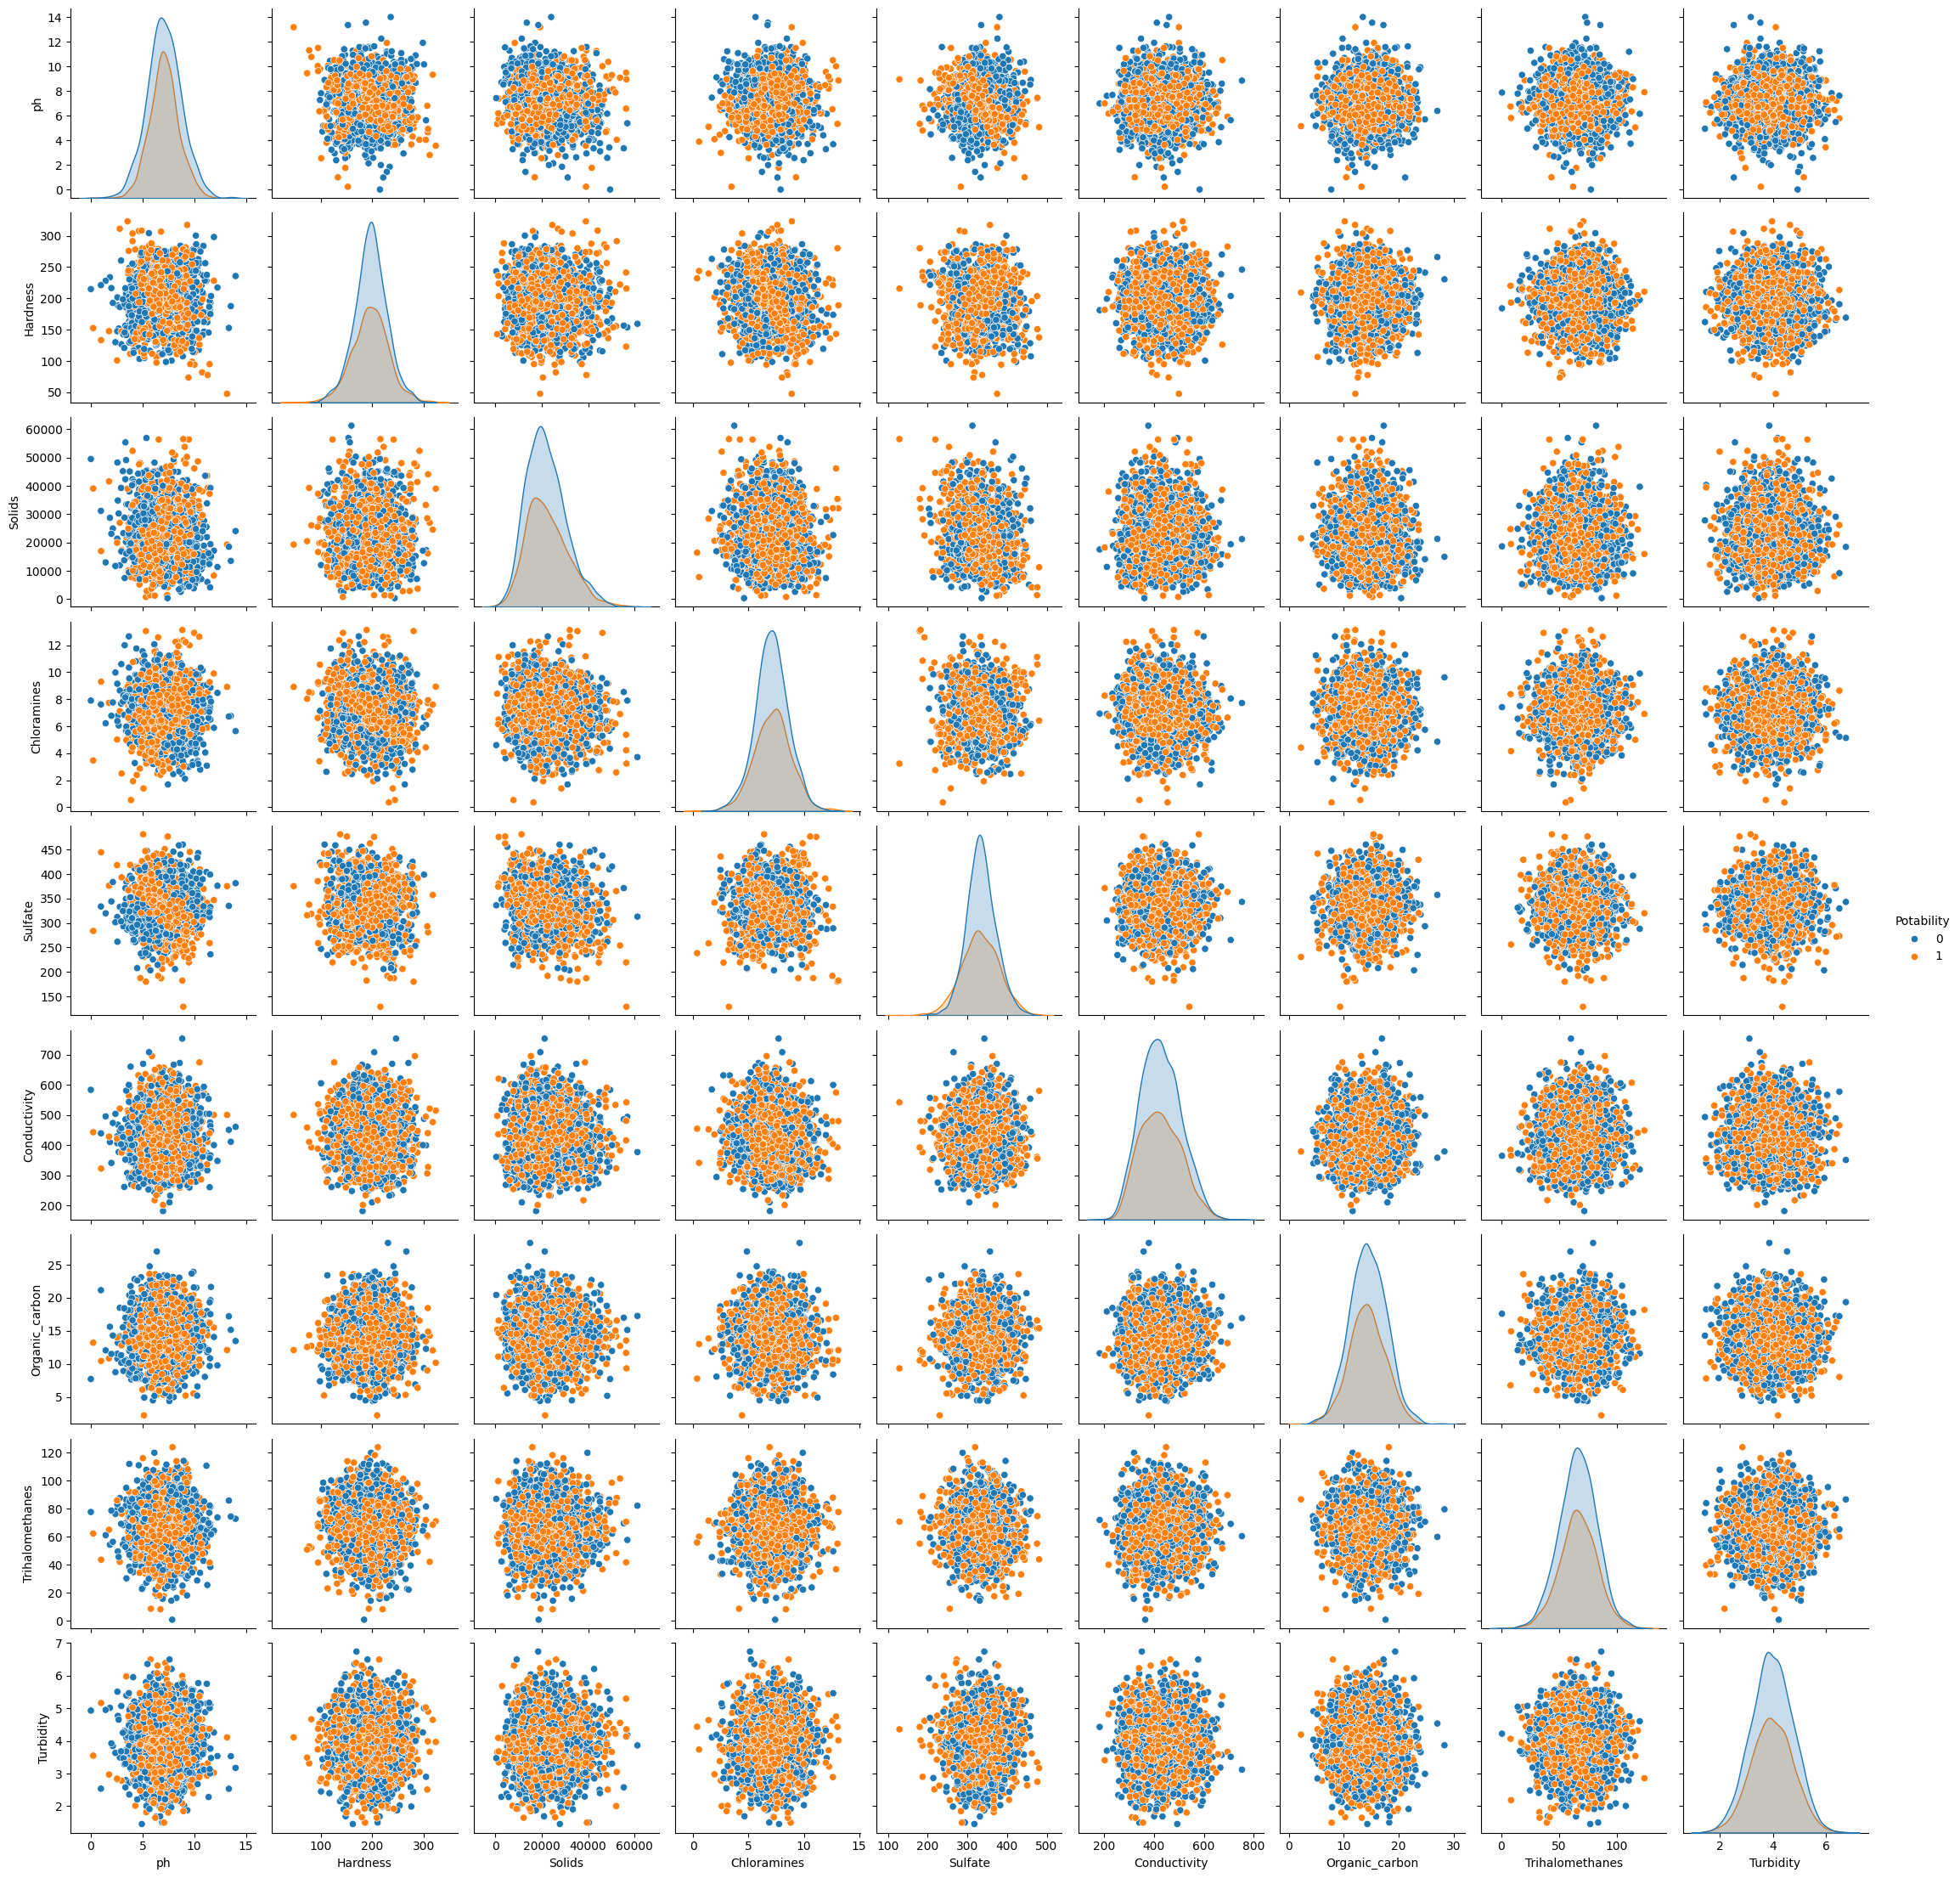

In [18]:
sns.pairplot(df, hue="Potability")

the above pairplot graph is according to the potability with repect to the specific feature.
Both Co-relation matrix & Paiplot says that there is no linear relationship between the features that can explan the target variable.

# Data Preparation and Feature Engineering

In [19]:
df[df['Potability']==1].describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,1101.000000,1278.000000,1278.000000,1278.000000,985.000000,1278.000000,1278.000000,1223.000000,1278.000000,1278.0
mean,7.073783,195.800744,22383.991018,7.169338,332.566990,425.383800,14.160893,66.539684,3.968328,1.0
std,1.448048,35.547041,9101.010208,1.702988,47.692818,82.048446,3.263907,16.327419,0.780842,0.0
min,0.227499,47.432000,728.750830,0.352000,129.000000,201.619737,2.200000,8.175876,1.492207,1.0
25%,6.179312,174.330531,15668.985035,6.094134,300.763772,360.939023,12.033897,56.014249,3.430909,1.0
50%,7.036752,196.632907,21199.386614,7.215163,331.838167,420.712729,14.162809,66.678214,3.958576,1.0
75%,7.933068,218.003420,27973.236446,8.199261,365.941346,484.155911,16.356245,77.380975,4.509569,1.0
max,13.175402,323.124000,56488.672413,13.127000,481.030642,695.369528,23.604298,124.000000,6.494249,1.0


In [20]:
df[df['Potability']==0].describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,1684.000000,1998.000000,1998.000000,1998.000000,1510.000000,1998.000000,1998.000000,1891.000000,1998.000000,1998.0
mean,7.085378,196.733292,21777.490788,7.092175,334.564290,426.730454,14.364335,66.303555,3.965800,0.0
std,1.683499,31.057540,8543.068788,1.501045,36.745549,80.047317,3.334554,16.079320,0.780282,0.0
min,0.000000,98.452931,320.942611,1.683993,203.444521,181.483754,4.371899,0.738000,1.450000,0.0
25%,6.037723,177.823265,15663.057382,6.155640,311.264006,368.498530,12.101057,55.706530,3.444062,0.0
50%,7.035456,197.123423,20809.618280,7.090334,333.389426,422.229331,14.293508,66.542198,3.948076,0.0
75%,8.155510,216.120687,27006.249009,8.066462,356.853897,480.677198,16.649485,77.277704,4.496106,0.0
max,14.000000,304.235912,61227.196008,12.653362,460.107069,753.342620,28.300000,120.030077,6.739000,0.0


as we can see that their is a slight diffrence between the mean where the potability =0 and potability = 1 as our data is imbalance.
so we have to keep that in mind for doing analysis.

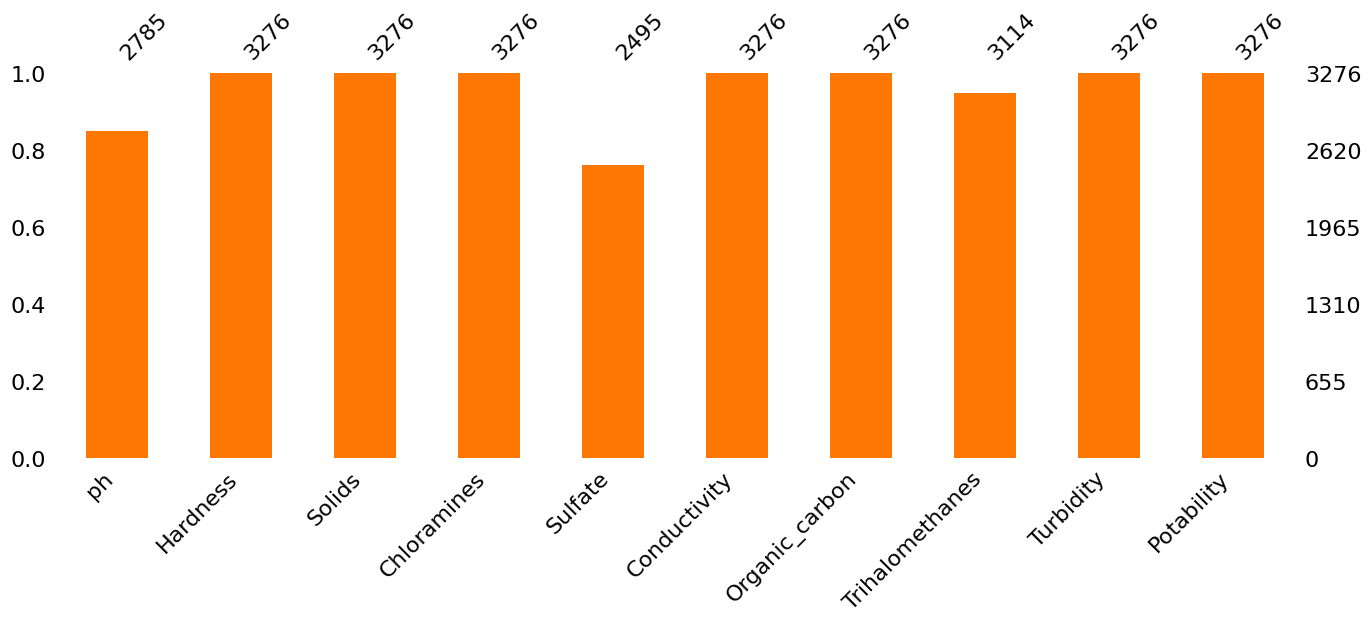

In [21]:
msno.bar(df, figsize = (16,5),color = '#FD7702')
plt.show()

above graph shows , how much our data regarding to the specific feature is filled.

In [22]:
df[df['Sulfate'].isnull()]
df[df['ph'].isnull()]
df[df['Trihalomethanes'].isnull()]

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
62,NaN,229.485694,35729.692709,8.810843,384.943779,296.397547,16.927092,NaN,3.855602,0
81,5.519126,168.728583,12531.601921,7.730723,NaN,443.570372,18.099078,NaN,3.758996,0
110,9.286155,222.661551,12311.268366,7.289866,332.239359,353.740100,14.171763,NaN,5.239982,0
118,7.397413,122.541040,8855.114121,6.888689,241.607532,489.851600,13.365906,NaN,3.149158,0
119,7.812804,196.583886,42550.841816,7.334648,NaN,442.545775,14.666917,NaN,6.204846,0
...,...,...,...,...,...,...,...,...,...,...
3174,6.698154,198.286268,34675.862845,6.263602,360.232834,430.935009,12.176678,NaN,3.758180,1
3185,6.110022,234.800957,16663.539074,5.984536,348.055211,437.892115,10.059523,NaN,2.817780,1
3219,6.417716,209.702425,31974.481631,7.263425,321.382124,289.450118,11.369071,NaN,4.210327,1
3259,9.271355,181.259617,16540.979048,7.022499,309.238865,487.692788,13.228441,NaN,4.333953,1


In [23]:
#Filling the missing values with their column mean gerouped by different Portability Status

df['ph']=df['ph'].fillna(df.groupby(['Potability'])['ph'].transform('mean'))
df['Sulfate']=df['Sulfate'].fillna(df.groupby(['Potability'])['Sulfate'].transform('mean'))
df['Trihalomethanes']=df['Trihalomethanes'].fillna(df.groupby(['Potability'])['Trihalomethanes'].transform('mean'))

we used group by method to handle the null values due to the imbalance dataset.

In [24]:
df.isna().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

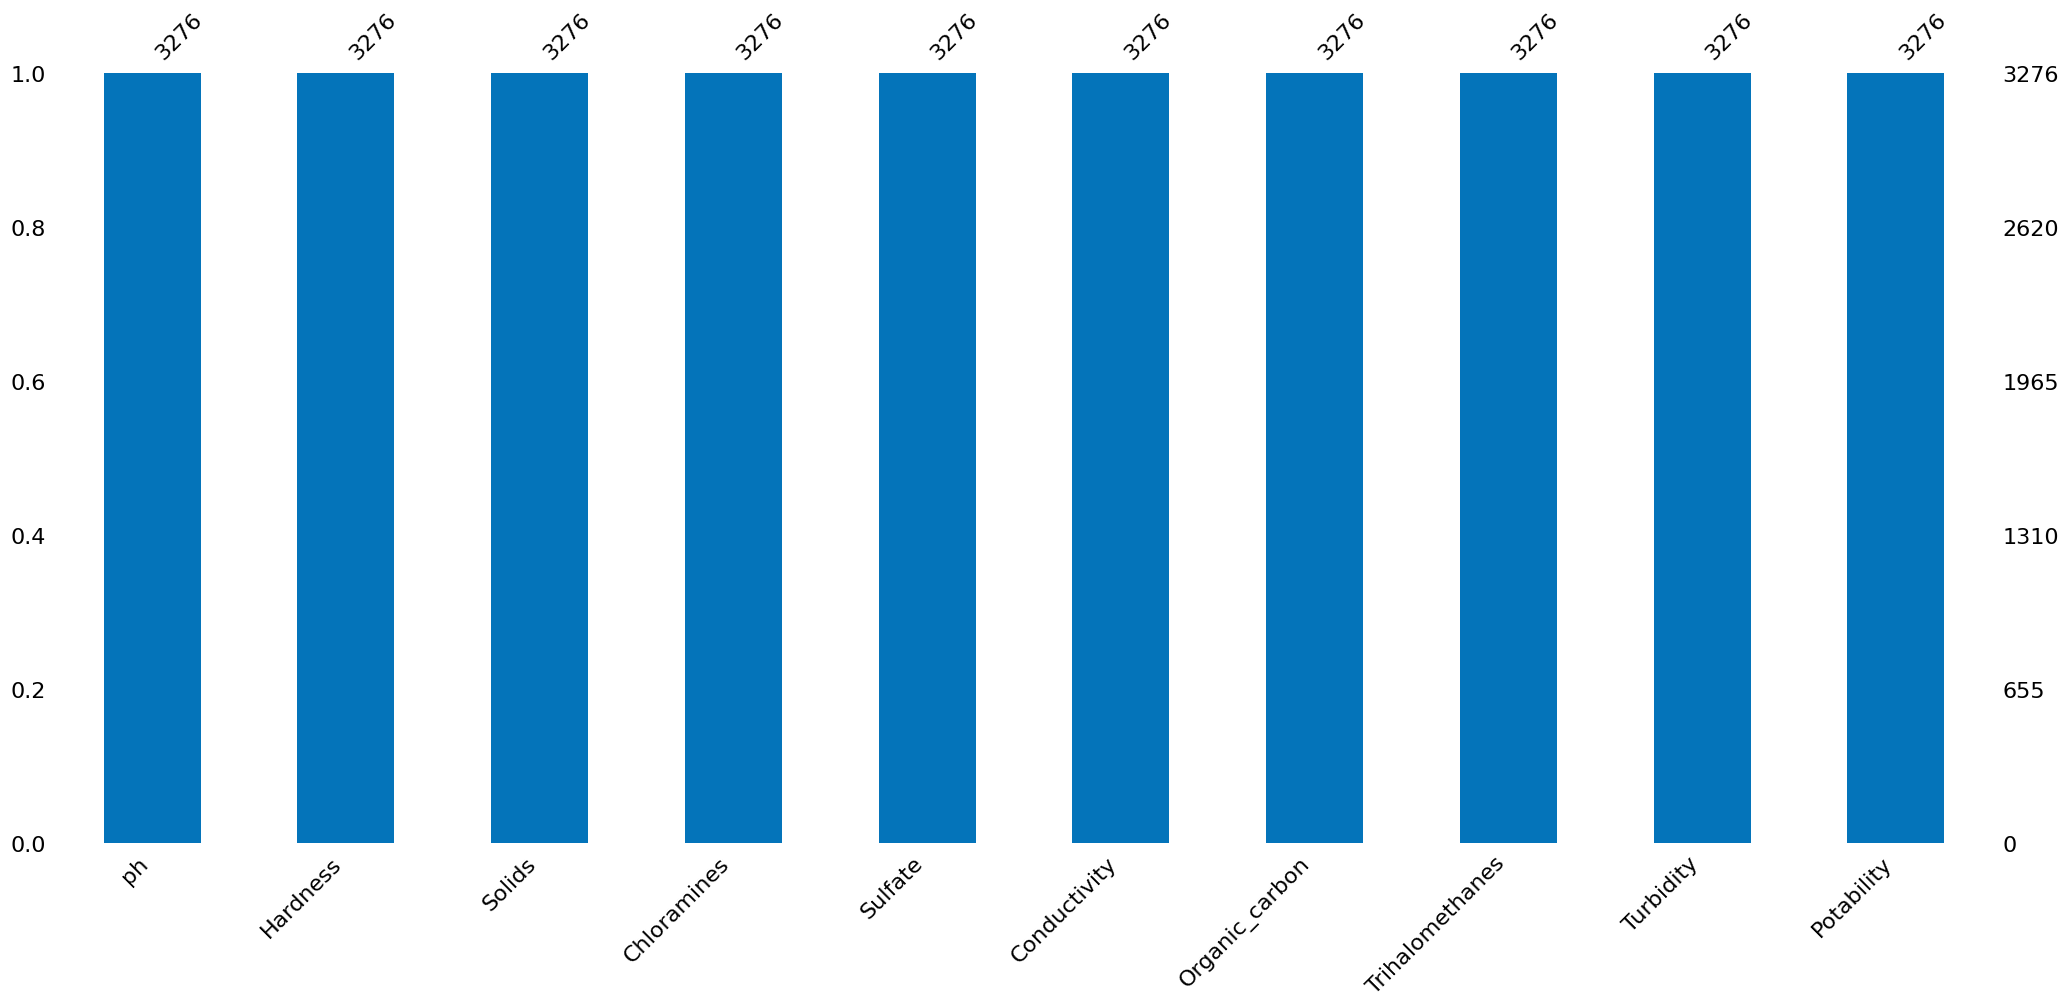

In [25]:
fig = msno.bar(df, color='#0474BA')

now the null values are filled by group by mean according to the potable and non-potable data

# Modelling

In [26]:
# Models
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

# Evaluation & CV Libraries
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, cross_val_score


In [27]:
X = df.drop('Potability', axis=1)
y = df['Potability']

Partitioning the dataset into train dataset and test dataset in 4:1. And Standardizing and Normalizing the train dataset

In [28]:
#Partitioning the dataset in training set and test set
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)

#Standardizing and Normalising the data set
scale = StandardScaler()
X_train=scale.fit_transform(X_train)
X_test=scale.transform(X_test)

**Logistic Regression**

Logistic Regression is a statistical method used for binary classification problems.
It models the probability that a given input belongs to a particular class.
The logistic regression model uses the sigmoid activation function to squash the output between 0 and 1.

Here is the report for the logistic regression model during training.


c:\users\hp\appdata\local\programs\python\python38\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\users\hp\appdata\local\programs\python\python38\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\users\hp\appdata\local\programs\python\python38\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, m

              precision    recall  f1-score   support

           0       0.63      1.00      0.77       412
           1       0.00      0.00      0.00       244

    accuracy                           0.63       656
   macro avg       0.31      0.50      0.39       656
weighted avg       0.39      0.63      0.48       656

0.6280487804878049


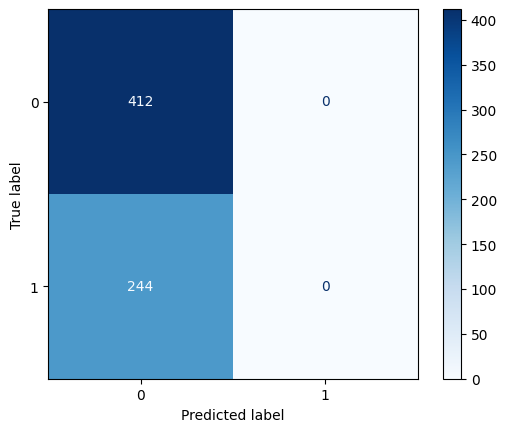

In [29]:
finalResults = []
#Performing Logistic Regression
LR_model = LogisticRegression(max_iter=1000)
LR_model.fit(X_train, y_train)

#Predicting on test dataset
y_pred = LR_model.predict(X_test)
y_train_pred = LR_model.predict(X_train)

log1_acc = accuracy_score(y_test, y_pred)
finalResults.append(("LR",log1_acc))

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=LR_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LR_model.classes_)
disp.plot(cmap=plt.cm.Blues)
print(log1_acc)

**Support Vector Machine**

SVM is a powerful supervised learning algorithm for both classification and regression tasks. It works by finding the hyperplane that best separates the classes in the feature space.

Here is the report for the Support Vector Machine model during training.

              precision    recall  f1-score   support

           0       0.70      0.92      0.79       412
           1       0.71      0.33      0.45       244

    accuracy                           0.70       656
   macro avg       0.70      0.62      0.62       656
weighted avg       0.70      0.70      0.67       656

0.6996951219512195


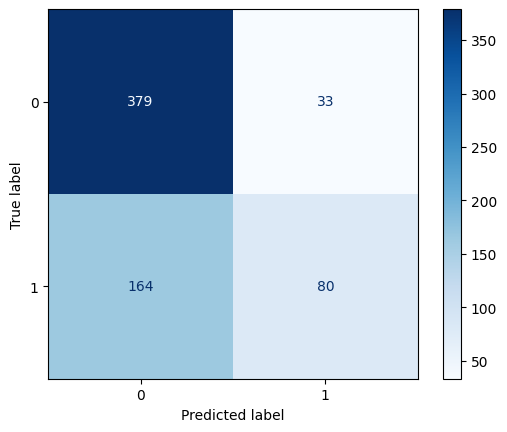

In [30]:
#Performing Support Vector Machine
SVC_model = SVC()
SVC_model.fit(X_train, y_train)

#Predicting on test dataset
y_pred = SVC_model.predict(X_test)
y_train_pred = SVC_model.predict(X_train)

log1_acc = accuracy_score(y_test, y_pred)
finalResults.append(("SVC",log1_acc))

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=SVC_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=SVC_model.classes_)
disp.plot(cmap=plt.cm.Blues)
print(log1_acc)

**K-Neighbors Classifier**

KNN is a simple yet effective algorithm for classification tasks. It classifies data points based on the majority class of their nearest neighbors in the feature space.

Here is the report for the K-Neighbors Classifier model during training using 10 neighbors.

              precision    recall  f1-score   support

           0       0.67      0.90      0.77       412
           1       0.61      0.27      0.37       244

    accuracy                           0.66       656
   macro avg       0.64      0.58      0.57       656
weighted avg       0.65      0.66      0.62       656

0.663109756097561


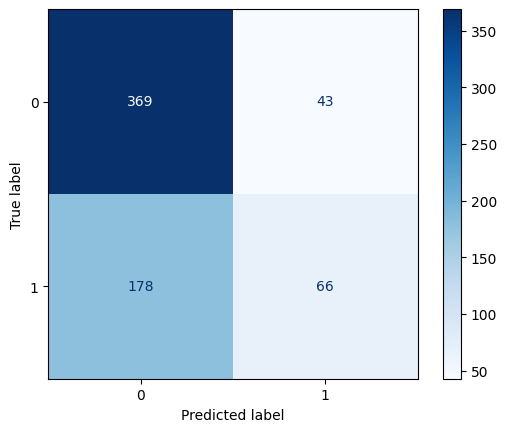

In [31]:
#Performing K-Neighbors Classifier
KNN_model = KNeighborsClassifier(n_neighbors=10)
KNN_model.fit(X_train, y_train)

#Predicting on test dataset
y_pred = KNN_model.predict(X_test)
y_train_pred = KNN_model.predict(X_train)

log1_acc = accuracy_score(y_test, y_pred)
finalResults.append(("KNN",log1_acc))

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=KNN_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=KNN_model.classes_)
disp.plot(cmap=plt.cm.Blues)
print(log1_acc)

**Decision Tree Classifier**

Decision trees recursively split the data into subsets based on the most significant features, creating a tree-like structure of decision rules.

Here is the report for the Decision Tree Classifier model during training.

              precision    recall  f1-score   support

           0       0.78      0.79      0.79       412
           1       0.64      0.62      0.63       244

    accuracy                           0.73       656
   macro avg       0.71      0.71      0.71       656
weighted avg       0.73      0.73      0.73       656

0.7286585365853658


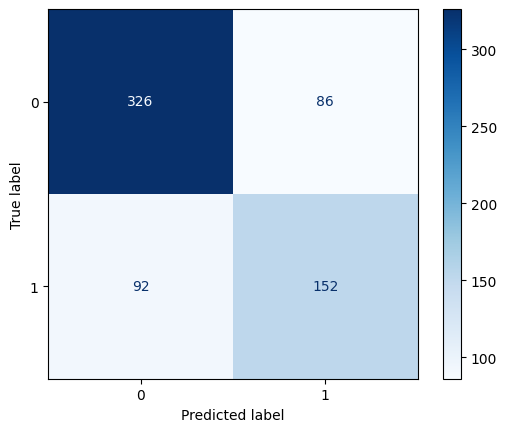

In [32]:
#Performing Decision Tree Classifier
DTC_model = DecisionTreeClassifier()
DTC_model.fit(X_train, y_train)

#Predicting on test dataset
y_pred = DTC_model.predict(X_test)
y_train_pred = DTC_model.predict(X_train)

log1_acc = accuracy_score(y_test, y_pred)
finalResults.append(("DTC",log1_acc))

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=DTC_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=DTC_model.classes_)
disp.plot(cmap=plt.cm.Blues)
print(log1_acc)

**Naive Bayes**

Naive Bayes is a probabilistic classifier based on Bayes' theorem with the assumption of feature independence.

Here is the report for the Naive Bayes model during training.

              precision    recall  f1-score   support

           0       0.65      0.88      0.75       412
           1       0.51      0.22      0.30       244

    accuracy                           0.63       656
   macro avg       0.58      0.55      0.53       656
weighted avg       0.60      0.63      0.58       656

0.6310975609756098


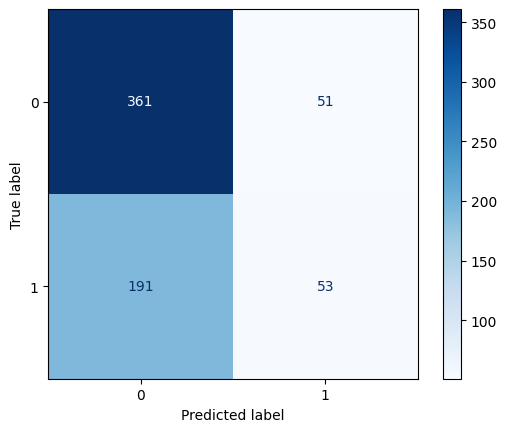

In [33]:
#Performing Naive Bayes
GNB_model = GaussianNB()
GNB_model.fit(X_train, y_train)

#Predicting on test dataset
y_pred = GNB_model.predict(X_test)
y_train_pred = GNB_model.predict(X_train)

log1_acc = accuracy_score(y_test, y_pred)
finalResults.append(("GNB",log1_acc))

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=GNB_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=GNB_model.classes_)
disp.plot(cmap=plt.cm.Blues)
print(log1_acc)

**Random Forest Classifier**

Random forests are an ensemble learning technique that builds multiple decision trees and combines their predictions to improve accuracy and reduce overfitting.

Here is the report for the Random Forest Classifier model during training.

              precision    recall  f1-score   support

           0       0.81      0.91      0.86       412
           1       0.81      0.63      0.71       244

    accuracy                           0.81       656
   macro avg       0.81      0.77      0.78       656
weighted avg       0.81      0.81      0.80       656

0.8064024390243902


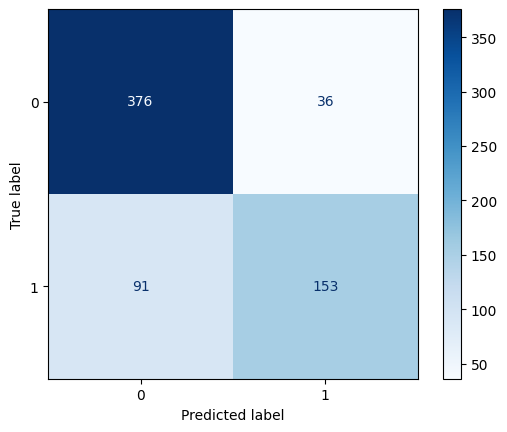

In [34]:
#Performing Random Forest Classifier
RF_model = RandomForestClassifier()
RF_model.fit(X_train, y_train)

#Predicting on test dataset
y_pred = RF_model.predict(X_test)
y_train_pred = RF_model.predict(X_train)

log1_acc = accuracy_score(y_test, y_pred)
finalResults.append(("RF",log1_acc))

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=RF_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=RF_model.classes_)
disp.plot(cmap=plt.cm.Blues)
print(log1_acc)

**Gradient Boosting Classifier**

GBM is another ensemble method that builds trees sequentially, with each tree aiming to correct the errors of its predecessor.

Here is the report for the Gradient Boosting Classifier model during training.

              precision    recall  f1-score   support

           0       0.79      0.93      0.85       412
           1       0.83      0.58      0.68       244

    accuracy                           0.80       656
   macro avg       0.81      0.76      0.77       656
weighted avg       0.80      0.80      0.79       656

0.8003048780487805


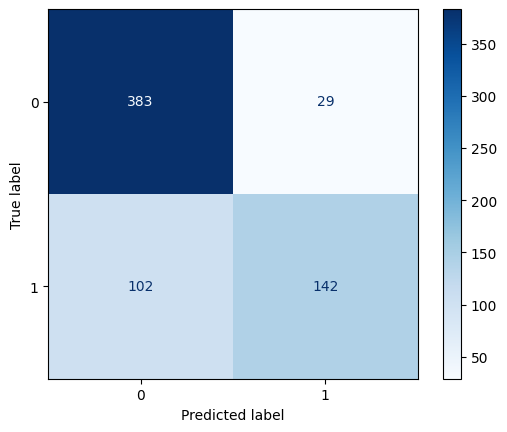

In [35]:
#Performing Gradient Boosting Classifier
XGB_model = GradientBoostingClassifier()
XGB_model.fit(X_train, y_train)

#Predicting on test dataset
y_pred = XGB_model.predict(X_test)
y_train_pred = XGB_model.predict(X_train)

log1_acc = accuracy_score(y_test, y_pred)
finalResults.append(("XGB",log1_acc))

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=XGB_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=XGB_model.classes_)
disp.plot(cmap=plt.cm.Blues)
print(log1_acc)

# Final Result Comparision

Here is comparision on how each model worked based on their accuracy

In [36]:
finalResults.sort(key=lambda k:k[1],reverse=True)
finalResults

[('RF', 0.8064024390243902),
 ('XGB', 0.8003048780487805),
 ('DTC', 0.7286585365853658),
 ('SVC', 0.6996951219512195),
 ('KNN', 0.663109756097561),
 ('GNB', 0.6310975609756098),
 ('LR', 0.6280487804878049)]

C:\Users\HP\AppData\Local\Temp\ipykernel_21232\1211943566.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax= sns.barplot(data=final,x=final[1], y=final[0], orient='h', palette='Blues', saturation=0.4, linewidth=0.5)


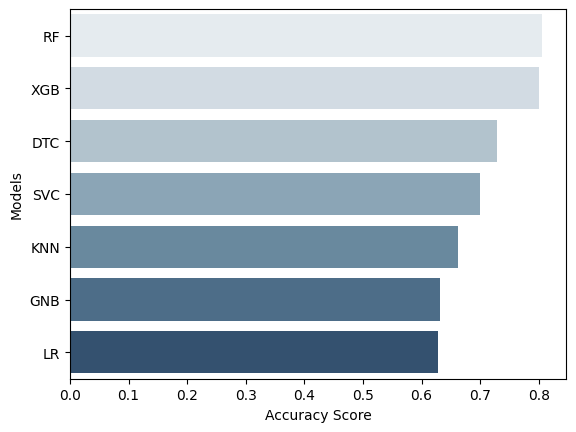

In [37]:
#Plotting the accuracy score against the models
final = pd.DataFrame(finalResults)
ax= sns.barplot(data=final,x=final[1], y=final[0], orient='h', palette='Blues', saturation=0.4, linewidth=0.5)
ax.set(xlabel='Accuracy Score', ylabel='Models')
plt.show()

To enhance the accuracy of the classifier, it was concluded that using random forest would be the best choice, potentially achieving up to 80.3% accuracy. However, it was deemed that the current classifiers provided satisfactory analysis of water potability.
Furthermore, it is recommended to do hyper tuning  of the features this will slightly increase the accuracy.